ModelPrivacy package Vignette
=========================================


June 23, 2022

# Introduction

We develop a new statistical notion of model privacy to study the model stealing attack. This package provides implementation of common attack and defense algorithms, along with the novel proposed defense mechanisms.  

In the follows, we use MNIST dataset as an example to illustrate how to defend model stealing attack with common defending mechanisms.  

## Prepration and data loading

In [1]:
import ModelPrivacy as mp
from ModelPrivacy.nn import run, cal_an
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torchvision
import torch.nn as nn
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
class LeNet5(nn.Module):
    """Network used by the defender and attacker."""
    # require 32*32 pixels
    def __init__(self, n_classes):
        super(LeNet5, self).__init__()
        
        self.feature_extractor = nn.Sequential(            
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=n_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return probs

def myCustomLoss(my_outputs, my_labels):
    '''Misclassification error.'''
    #specifying the batch size
    my_batch_size = my_outputs.size()[0] 

    my_outputs = torch.argmax(my_outputs, axis=1)  
    if my_labels.dim() == 2: my_labels = torch.argmax(my_labels, axis=1)
    #returning the results
    return torch.sum(my_outputs != my_labels)/my_batch_size

In [3]:
# detect gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Reshape the image to 32*32 to use LeNet5
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((32, 32)),                          
    torchvision.transforms.ToTensor()])

# Need change to local path of your data
path = '/home/gwang/PycharmProjects/DL/data'
# Load data
mnist_trainset = datasets.MNIST(root=path, train=True, download=False, transform=transform)
mnist_testset = datasets.MNIST(root=path, train=False, download=False, transform=transform)

# Split data to teacher's training data and attacker's queries
mnist_trainset, valid = torch.utils.data.random_split(mnist_trainset, (10000, 50000))

batch_size = 128
trainloader = torch.utils.data.DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(mnist_testset, batch_size=batch_size, shuffle=True)

Quick look at the samples

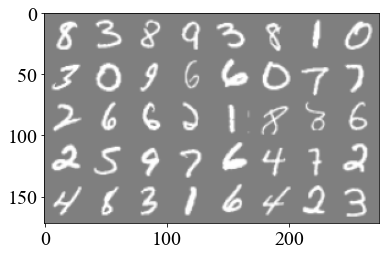

In [4]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.next()
# show images
imshow(torchvision.utils.make_grid(images[:40]))

## Teacher (defender's) model 

In [5]:
trainloader = torch.utils.data.DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True)
train_loss, test_loss, teacher = run(trainloader, testloader, LeNet5(10).to(device), 
                                     criterion2 = myCustomLoss, device=device, num_epochs=50, verbose=False)

In [6]:
'Teacher 0-1 loss on test data: %.3f' % test_loss

'Teacher 0-1 loss on test data: 0.025'

## Defense mechanisms (our contribution)

Assume the attacker send 1000 queries from the same distribution (i.e., from the validation dataset we split at the beginning).

In [8]:
n = 1000
query = torch.utils.data.Subset(datasets.MNIST(path, train=True, download=False, transform=transform), 
                                valid.indices[:n])
queryloader = torch.utils.data.DataLoader(query, batch_size=batch_size, shuffle=True)

# Record the privacy gain (test error) and the utility loss (noise level)
methods = ['Base', 'RN', 'AM']
df = pd.DataFrame(np.zeros((2, 3)), columns=methods, index = ['Test error', 'Noise level'])

### No defense

In [9]:
# Defense is the base defense class, which doesn't perturb the teacher model's outputs
m = mp.Defense(queryloader, teacher, device=device)
# sample method prepares the dataloader for the attacker to rebuild the model
trainloader = m.sample()
train_loss, test_loss, student = run(trainloader, testloader, LeNet5(10).to(device),
                                     criterion2 = myCustomLoss, device=device, num_epochs=100, verbose=False)

In [10]:
df['Base'] = [test_loss, cal_an(m, n, myCustomLoss)]
'No defense, student 0-1 loss on test data: %.3f' % test_loss

'No defense, student 0-1 loss on test data: 0.067'

### Random noise

In [11]:
# The first parameter of RandomNoise controls the variance of the noise
m = mp.RandomNoise(0.3, queryloader, teacher, device=device)
trainloader = m.sample()
train_loss, test_loss, student = run(trainloader, testloader, LeNet5(10).to(device),
                                     criterion2 = myCustomLoss, device=device, num_epochs=100, verbose=False)

In [12]:
df['RN'] = [test_loss, cal_an(m, n, myCustomLoss)]
'Random Noise Defense, student 0-1 loss on test data: %.3f' % test_loss

'Random Noise Defense, student 0-1 loss on test data: 0.111'

### Adaptive misinformation

In [13]:
# We need to train a mis-specified model at first
dig = {1:7, 2:3, 3:2, 4:0, 5:6, 6:5, 7:1, 8:9, 9:8, 0:4}
tmp = []
y = []
for d, l in mnist_trainset:
    tmp.append(d[None,])
    y.append(dig[l])
t_set = mp.SimData(torch.vstack(tmp), torch.Tensor(y).type(torch.long))
trainloader = torch.utils.data.DataLoader(t_set, batch_size=batch_size, shuffle=True)
train_loss, test_loss, mis_model = run(trainloader, testloader, LeNet5(10).to(device),
                                      criterion2 = myCustomLoss, device=device, num_epochs=10, verbose=False)

In [14]:
m = mp.AdaptiveNoise(mis_model, 0.99, -100, queryloader, teacher, device=device)
trainloader = m.sample(n)

In [15]:
train_loss, test_loss, student = run(trainloader, testloader, LeNet5(10).to(device),
                                     criterion2 = myCustomLoss, device=device, num_epochs=100, verbose=False)

In [16]:
df['AM'] = [test_loss, cal_an(m, n, myCustomLoss)]
'Adaptive Misinformation, student 0-1 loss on test data: %.3f' % test_loss

'Adaptive Misinformation, student 0-1 loss on test data: 0.112'

### Review

In [17]:
df

,Base,RN,AM
Test error,0.066752,0.110759,0.11165
Noise level,0.000000,0.075000,0.09000
